# 03 - Model Evaluation

## Evaluación comparativa de modelos supervisados

Este notebook corresponde a la tercera parte del proyecto. Su objetivo es evaluar comparativamente los modelos supervisados implementados en la etapa anterior.

Se comparan los siguientes modelos:

- Logistic Regression
- Decision Tree
- Support Vector Machine
- KNN

La evaluación se realiza utilizando métricas de clasificación apropiadas para el problema de abandono de clientes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de confusión

Como el objetivo de negocio es anticipar clientes con riesgo de abandono, no basta con mirar solamente accuracy. También es importante revisar recall y F1-score, porque interesa detectar correctamente a los clientes que podrían abandonar.


In [2]:
# Importación de librerías principales para manipulación de datos.
import pandas as pd
import numpy as np

# Librerías para visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Scikit-learn para división de datos, pipelines y preprocesamiento.
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Herramientas de imputación, escalamiento y codificación.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos supervisados utilizados.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas de evaluación.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Configuración visual general.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1. Carga del dataset

Se utiliza el mismo dataset del caso de estudio de abandono de clientes. La variable objetivo es `abandono`, que indica si el cliente abandona o no el servicio.

Este es un problema de clasificación binaria, porque la respuesta esperada tiene dos clases posibles.


In [3]:
def cargar_datos(url):
    """ Función que recibe la url del archivo a leer """
    df = pd.read_csv(url)
    print("Dataset cargado correctamente")
    print(df.head(5))
    return df

url = "https://raw.githubusercontent.com/magomezn-debug/dScience_001D/main/data/datos_clientes_limpios.csv"

# para cargar datos
df = cargar_datos(url)

# Visualización inicial del tamaño del dataset.
print('Dimensiones del dataset:', df.shape)

# Vista inicial de las primeras filas.
df.head()

Dataset cargado correctamente
   edad  ingreso_mensual  gasto_mensual   deuda_total  score_crediticio  \
0  66.0     9.243057e+05  524088.303055  2.448145e+06        455.406680   
1  51.0     1.384687e+06  314259.751474  1.620569e+06        575.048508   
2  48.0     8.047533e+05  387192.316142  5.395040e+06        770.716904   
3  54.0     4.369032e+05  417328.601856  2.999350e+06        442.722671   
4  31.0     7.408561e+05  490961.191253  1.637711e+06        468.188403   

   antiguedad_meses  frecuencia_compra  ultima_compra_dias  num_productos  \
0             101.0                6.0               356.0            3.0   
1              65.0                8.0               307.0            4.0   
2               1.0               12.0               232.0            4.0   
3               4.0                3.0               165.0            2.0   
4              14.0                5.0               283.0            3.0   

   genero_Masculino  ...  tipo_plan_Premium  canal_regis

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,genero_Masculino,...,tipo_plan_Premium,canal_registro_Tienda,canal_registro_Web,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,abandono
0,66.0,9.243057e+05,524088.303055,2.448145e+06,455.406680,101.0,6.0,356.0,3.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
1,51.0,1.384687e+06,314259.751474,1.620569e+06,575.048508,65.0,8.0,307.0,4.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2,48.0,8.047533e+05,387192.316142,5.395040e+06,770.716904,1.0,12.0,232.0,4.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,54.0,4.369032e+05,417328.601856,2.999350e+06,442.722671,4.0,3.0,165.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,31.0,7.408561e+05,490961.191253,1.637711e+06,468.188403,14.0,5.0,283.0,3.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1


## 2. Separación de variables predictoras y variable objetivo

La variable `abandono` corresponde a la variable objetivo `y`.

El resto de las columnas corresponden a variables predictoras `X`, es decir, la información que utilizarán los modelos para aprender patrones.


In [4]:
# Separación de variables predictoras y variable objetivo.
X = df.drop('abandono', axis=1)
y = df['abandono']

# División en entrenamiento y prueba.
# stratify=y mantiene proporciones similares de abandono/no abandono en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño de X_train:', X_train.shape)
print('Tamaño de X_test:', X_test.shape)
print('Distribución de y_train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nDistribución de y_test:')
print(y_test.value_counts(normalize=True).round(3))

Tamaño de X_train: (16000, 27)
Tamaño de X_test: (4000, 27)
Distribución de y_train:
abandono
0    0.603
1    0.397
Name: proportion, dtype: float64

Distribución de y_test:
abandono
0    0.603
1    0.397
Name: proportion, dtype: float64


## 3. Identificación de variables numéricas y categóricas

Esta etapa es necesaria porque las variables numéricas y categóricas no se procesan igual.

- Las variables numéricas se imputan con mediana y se escalan.
- Las variables categóricas se imputan con la moda y se codifican con One Hot Encoding.

Esto permite que modelos como Logistic Regression, SVM y KNN reciban datos correctamente transformados.


In [5]:
# Identificación automática de columnas numéricas.
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identificación automática de columnas categóricas.
columnas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print('Columnas numéricas:')
print(columnas_numericas)

print('\nColumnas categóricas:')
print(columnas_categoricas)

Columnas numéricas:
['edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'genero_Masculino', 'genero_Otro', 'region_Norte', 'region_Sur', 'estado_civil_Divorciado', 'estado_civil_Soltero', 'uso_app_Bajo', 'uso_app_Medio', 'tipo_plan_Estandar', 'tipo_plan_Premium', 'canal_registro_Tienda', 'canal_registro_Web', 'dia_semana_registro_Jueves', 'dia_semana_registro_Lunes', 'dia_semana_registro_Martes', 'dia_semana_registro_Miercoles', 'dia_semana_registro_Sabado', 'dia_semana_registro_Viernes']

Columnas categóricas:
[]


## 4. Construcción del preprocesamiento

Se utiliza `ColumnTransformer` para aplicar tratamientos diferentes según el tipo de variable.

La imputación se incluye dentro del pipeline para evitar errores y mantener reproducibilidad. El escalamiento es importante porque Logistic Regression, SVM y KNN son sensibles a la escala de las variables.


In [6]:
# Pipeline para variables numéricas.
# La mediana es robusta frente a valores extremos.
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas.
# Se imputa con la categoría más frecuente y luego se aplica One Hot Encoding.
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer une ambos tratamientos.
preprocessor = ColumnTransformer([
    ('num', pipeline_numerico, columnas_numericas),
    ('cat', pipeline_categorico, columnas_categoricas)
])

print('Preprocesamiento construido correctamente.')

Preprocesamiento construido correctamente.


## 5. Definición de modelos

Se evalúan únicamente modelos alineados con lo visto en clases y con los contenidos relacionados de programación/preprocesamiento:

- Logistic Regression: modelo probabilístico e interpretable.
- Decision Tree: modelo basado en reglas.
- SVM: modelo basado en separación de clases y margen máximo.
- KNN: modelo basado en distancia, útil para conectar con escalamiento y preprocessing.


In [7]:
# Definición de modelos.
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

print('Modelos definidos:')
for nombre in modelos:
    print('-', nombre)

Modelos definidos:
- Logistic Regression
- Decision Tree
- SVM
- KNN


## 6. Entrenamiento y evaluación en conjunto de prueba

Se entrena cada modelo usando su pipeline completo. Luego se calculan métricas para comparar rendimiento.

Las métricas se interpretan de la siguiente manera:

- Accuracy: proporción total de aciertos.
- Precision: de los clientes predichos como abandono, cuántos realmente abandonan.
- Recall: de los clientes que realmente abandonan, cuántos detecta el modelo.
- F1-score: equilibrio entre precision y recall.
- ROC-AUC: capacidad general de separar entre abandono y no abandono.


In [32]:
# Lista para almacenar resultados.
resultados = []

# Diccionario para guardar modelos entrenados.
pipelines_entrenados = {}

# Entrenamiento y evaluación de cada modelo.
for nombre, modelo in modelos.items():

    # Se crea un pipeline completo: preprocesamiento + modelo.
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])

    # Entrenamiento del pipeline.
    pipeline.fit(X_train, y_train)

    # Predicción de clases.
    y_pred = pipeline.predict(X_test)

    # Predicción de probabilidades para ROC-AUC.
    if hasattr(pipeline.named_steps['model'], 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    # Cálculo de métricas.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Almacenamiento de resultados.
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

    # Guardar pipeline entrenado.
    pipelines_entrenados[nombre] = pipeline

# Conversión a DataFrame.
df_resultados = pd.DataFrame(resultados).sort_values(by='F1-score', ascending=False)

# Mostrar resultados.
df_resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6575,0.6067,0.3888,0.4739,0.6882
1,Decision Tree,0.5738,0.4620,0.4518,0.4568,0.5529
3,KNN,0.5802,0.4638,0.3718,0.4127,0.5739
2,SVM,0.6470,0.6112,0.3031,0.4052,0.6642


## 7. Visualización comparativa de métricas

Este gráfico permite comparar rápidamente el rendimiento de los modelos. Para este problema, F1-score y Recall son especialmente relevantes porque el objetivo es detectar clientes con riesgo de abandono.


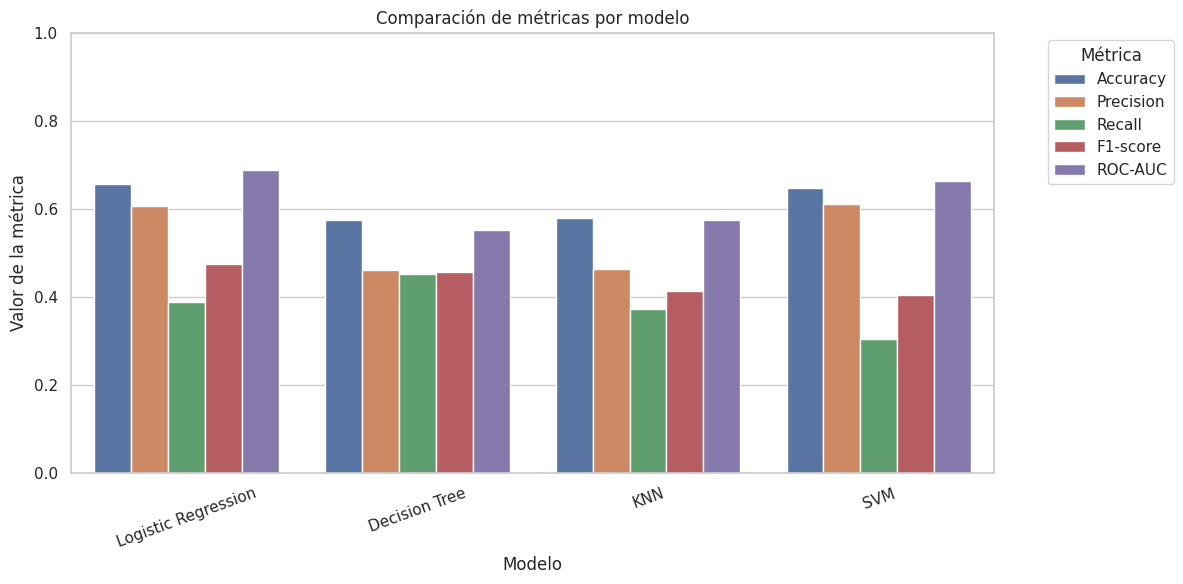

In [33]:
# Transformación de resultados a formato largo para graficar.
df_metricas_long = df_resultados.melt(
    id_vars='Modelo',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    var_name='Métrica',
    value_name='Valor'
)

# Gráfico comparativo.
plt.figure(figsize=(12, 6))
sns.barplot(data=df_metricas_long, x='Modelo', y='Valor', hue='Métrica')

plt.title('Comparación de métricas por modelo')
plt.xlabel('Modelo')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Matrices de confusión

La matriz de confusión permite analizar los errores del modelo. Para el problema de abandono, interesa especialmente reducir falsos negativos, es decir, clientes que sí abandonan pero el modelo predice como no abandono.

Ese error es importante para el negocio porque implica perder la oportunidad de aplicar una acción preventiva.


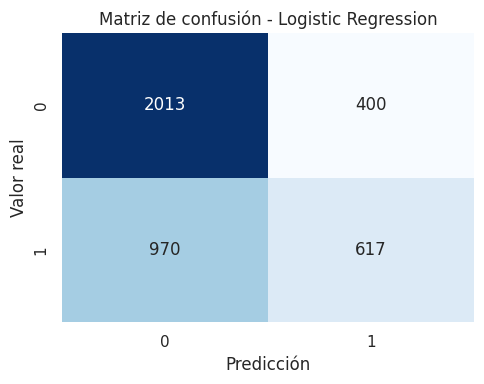

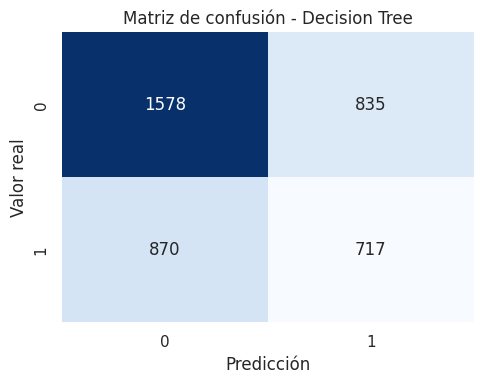

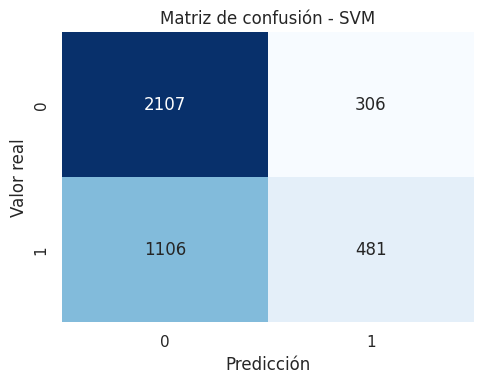

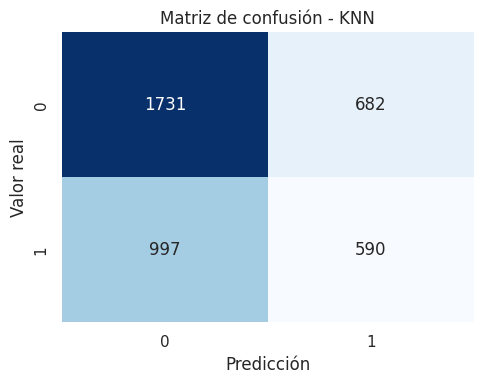

In [34]:
# Generación de matrices de confusión para cada modelo.
for nombre, pipeline in pipelines_entrenados.items():

    # Predicción del modelo.
    y_pred = pipeline.predict(X_test)

    # Cálculo de matriz de confusión.
    matriz = confusion_matrix(y_test, y_pred)

    # Visualización.
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False
    )

    plt.title(f'Matriz de confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Valor real')
    plt.tight_layout()
    plt.show()

## 9. Reporte de clasificación del mejor modelo según F1-score

Se selecciona inicialmente el modelo con mejor F1-score, ya que esta métrica equilibra precision y recall. Esta elección es adecuada cuando no se quiere evaluar únicamente aciertos generales, sino también el desempeño sobre la clase positiva de abandono.


In [35]:
# Selección del mejor modelo según F1-score.
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_pipeline = pipelines_entrenados[mejor_modelo_nombre]

# Predicción del mejor modelo.
y_pred_mejor = mejor_pipeline.predict(X_test)

print('Mejor modelo según F1-score:', mejor_modelo_nombre)
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_mejor, zero_division=0))

Mejor modelo según F1-score: Logistic Regression

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.67      0.83      0.75      2413
           1       0.61      0.39      0.47      1587

    accuracy                           0.66      4000
   macro avg       0.64      0.61      0.61      4000
weighted avg       0.65      0.66      0.64      4000



## 10. Validación cruzada

La validación cruzada permite evaluar la estabilidad del modelo usando diferentes particiones de entrenamiento. Esto reduce la dependencia de un único train/test split y entrega una evaluación más robusta.


In [36]:
# Métricas usadas en validación cruzada.
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Lista para almacenar resultados de validación cruzada.
resultados_cv = []

# Evaluación de cada modelo con cross-validation.
for nombre, modelo in modelos.items():

    # Pipeline completo.
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])

    # Validación cruzada.
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    # Guardar promedio y desviación estándar de F1.
    resultados_cv.append({
        'Modelo': nombre,
        'Accuracy_mean': scores['test_accuracy'].mean(),
        'Precision_mean': scores['test_precision'].mean(),
        'Recall_mean': scores['test_recall'].mean(),
        'F1_mean': scores['test_f1'].mean(),
        'ROC_AUC_mean': scores['test_roc_auc'].mean(),
        'F1_std': scores['test_f1'].std()
    })

# DataFrame final de validación cruzada.
df_cv = pd.DataFrame(resultados_cv).sort_values(by='F1_mean', ascending=False)

df_cv.round(4)

,Modelo,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean,F1_std
0,Logistic Regression,0.6504,0.5949,0.3735,0.4588,0.6759,0.0078
1,Decision Tree,0.5654,0.4535,0.4634,0.4584,0.5479,0.0114
3,KNN,0.5863,0.4737,0.3855,0.4251,0.5725,0.0097
2,SVM,0.6411,0.5926,0.3056,0.4031,0.6506,0.0082


## 11. Conclusión de la evaluación

Esta etapa permitió comparar los modelos desde distintas métricas. En un problema de abandono, el mejor modelo no debe elegirse solamente por accuracy, porque podría acertar muchos casos de no abandono y fallar en detectar clientes que sí abandonan.

Por eso, se priorizan métricas como recall y F1-score, que entregan una visión más útil para el negocio. Un modelo con buen recall permite detectar más clientes en riesgo, mientras que F1-score ayuda a equilibrar detección y precisión.

La elección final del modelo debe considerar rendimiento, estabilidad, interpretabilidad y utilidad para diseñar acciones preventivas.
